#개요

In [1]:
import pandas as pd
import numpy as np
import os
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/IBA_REG/train.csv")
test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/IBA_REG/test.csv")

In [4]:
# 테스트 데이터 결측치 확인
missing_values_test = test.isnull().sum()
print("테스트 데이터 결측치 개수:")
display(missing_values_test)

테스트 데이터 결측치 개수:


,0
id,0
brand,0
model,0
year,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58627 entries, 0 to 58626
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         58627 non-null  object 
 1   model         58627 non-null  object 
 2   year          58627 non-null  int64  
 3   transmission  58627 non-null  object 
 4   mileage       57849 non-null  float64
 5   fuelType      58627 non-null  object 
 6   tax           53515 non-null  float64
 7   mpg           53035 non-null  float64
 8   engineSize    58627 non-null  float64
 9   price         58627 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 4.5+ MB


# mileage 결측치 대체


In [6]:
# 연도와 모델별 'mileage' 중앙값 계산
mileage_median_by_year_model = train.groupby(['year', 'model'])['mileage'].transform('median')

# 계산된 그룹별 중앙값으로 'mileage' 결측값 채우기
train['mileage'] = train['mileage'].fillna(mileage_median_by_year_model)

# 남아있는 결측값을 위해 연도별 'mileage' 중앙값 계산
mileage_median_by_year = train.groupby('year')['mileage'].transform('median')

# 남아있는 'mileage' 결측값을 계산된 연도별 중앙값으로 채우기
train['mileage'] = train['mileage'].fillna(mileage_median_by_year)

# 여전히 남아있는 결측값은 전체 중앙값으로 채우기 (폴백)
train['mileage'] = train['mileage'].fillna(train['mileage'].median())

# 'mileage'에 더 이상 결측값이 없는지 확인
print("결측값 대체 후 'mileage'의 결측값 개수:", train['mileage'].isnull().sum())

결측값 대체 후 'mileage'의 결측값 개수: 0


#i3 대체

In [7]:
# Filter rows where model is ' i3'
i3_model_rows_indices = train[train['model'] == ' i3'].index

# Change the 'mpg' value to 39 for these rows
train.loc[i3_model_rows_indices, 'mpg'] = 39

# Verify the changes (optional)
print("'model'이 'i3'인 행들의 'mpg' 값 변경 후:")
display(train[train['model'] == ' i3'])

'model'이 'i3'인 행들의 'mpg' 값 변경 후:


,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
1069,bmw,i3,2016,Automatic,20013.0,Hybrid,0.0,39.0,0.0,19875
2052,bmw,i3,2015,Automatic,79830.0,Hybrid,0.0,39.0,0.0,12500
2156,bmw,i3,2016,Automatic,43695.0,Hybrid,0.0,39.0,0.0,16482
4165,bmw,i3,2017,Automatic,24041.0,Hybrid,0.0,39.0,0.0,21495
4398,bmw,i3,2016,Automatic,25269.0,Other,0.0,39.0,0.6,17100
6061,bmw,i3,2017,Automatic,41949.0,Hybrid,140.0,39.0,0.0,19998
8963,bmw,i3,2017,Automatic,26965.0,Hybrid,NaN,39.0,0.0,19980
9173,bmw,i3,2017,Automatic,29851.0,Hybrid,0.0,39.0,0.0,19895
10385,bmw,i3,2016,Automatic,9990.0,Electric,NaN,39.0,0.0,18999
11032,bmw,i3,2015,Automatic,9886.0,Hybrid,0.0,39.0,0.0,17481


In [8]:
import pandas as pd
import numpy as np

# Load a fresh copy of the train data
train_temp = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/IBA_REG/train.csv")

# --- Reapply mileage imputation to get to the state before 'i3' mpg modification ---
# This part replicates cell 158a1294

# Calculate median mileage by year and model
mileage_median_by_year_model_temp = train_temp.groupby(['year', 'model'])['mileage'].transform('median')
train_temp['mileage'] = train_temp['mileage'].fillna(mileage_median_by_year_model_temp)

# Calculate median mileage by year for remaining NaNs
mileage_median_by_year_temp = train_temp.groupby('year')['mileage'].transform('median')
train_temp['mileage'] = train_temp['mileage'].fillna(mileage_median_by_year_temp);

# Fill any still remaining NaNs with overall median
train_temp['mileage'] = train_temp['mileage'].fillna(train_temp['mileage'].median())

# --- State BEFORE 'i3' mpg modification ---
print("--- 'i3' mpg 변경 전의 전체 mpg 평균 및 중앙값 ---")
# Check if any ' i3' models had mpg 470.8 before modification
i3_original_mpg_values = train_temp[train_temp['model'] == ' i3']['mpg'].unique()
if 470.8 in i3_original_mpg_values:
    print(f"' i3' 모델 중 원본 mpg가 470.8인 경우가 있었습니다. (현재 이 값은 대체되지 않은 상태)")
else:
    print(f"' i3' 모델 중 원본 mpg가 470.8인 경우는 없었습니다. (원래 mpg 값: {i3_original_mpg_values})")

mean_mpg_before = train_temp['mpg'].mean()
median_mpg_before = train_temp['mpg'].median()
print(f"전체 mpg 평균 (변경 전): {mean_mpg_before:.2f}")
print(f"전체 mpg 중앙값 (변경 전): {median_mpg_before:.2f}\n")

# --- Apply 'i3' mpg modification (as in cell pWJMxmO2o_0a) ---

# Filter rows where model is ' i3'
i3_model_rows_indices_temp = train_temp[train_temp['model'] == ' i3'].index

# Change the 'mpg' value to 39 for these rows
train_temp.loc[i3_model_rows_indices_temp, 'mpg'] = 39

# --- State AFTER 'i3' mpg modification ---
print("--- 'i3' mpg 변경 후의 전체 mpg 평균 및 중앙값 ---")
mean_mpg_after = train_temp['mpg'].mean()
median_mpg_after = train_temp['mpg'].median()
print(f"전체 mpg 평균 (변경 후): {mean_mpg_after:.2f}")
print(f"전체 mpg 중앙값 (변경 후): {median_mpg_after:.2f}")

--- 'i3' mpg 변경 전의 전체 mpg 평균 및 중앙값 ---
' i3' 모델 중 원본 mpg가 470.8인 경우가 있었습니다. (현재 이 값은 대체되지 않은 상태)
전체 mpg 평균 (변경 전): 55.25
전체 mpg 중앙값 (변경 전): 54.30

--- 'i3' mpg 변경 후의 전체 mpg 평균 및 중앙값 ---
전체 mpg 평균 (변경 후): 55.02
전체 mpg 중앙값 (변경 후): 54.30


#fuel type hybrid 대체

In [9]:
# 'mpg' 열을 숫자로 변환 (오류 발생 시 결측치로 처리)
train['mpg'] = pd.to_numeric(train['mpg'], errors='coerce')

# 'fuelType'이 'Other'이고 'mpg'가 100 이상인 행 조건 정의
# 'mpg'가 결측치인 경우는 조건에서 제외됩니다.
condition_replace_other_to_hybrid = (train['fuelType'] == 'Other') & (train['mpg'] >= 100)

# 조건에 해당하는 행의 'fuelType' 값을 'Hybrid'로 대체
rows_changed_count = train.loc[condition_replace_other_to_hybrid, 'fuelType'].shape[0]
train.loc[condition_replace_other_to_hybrid, 'fuelType'] = 'Hybrid'

# 변경된 행 수 확인 (선택 사항)
print(f"'fuelType'이 'Other'이고 'mpg' >= 100인 행 중 {rows_changed_count}개가 'Hybrid'로 대체되었습니다.")

# 'fuelType'의 분포 확인 (선택 사항)
print("\n'fuelType' 분포 (대체 후):")
display(train['fuelType'].value_counts())

# 'mpg' 변환 후 결측치 개수 확인 (선택 사항)
print("\n'mpg' 변환 후 결측치 개수:", train['mpg'].isnull().sum())

'fuelType'이 'Other'이고 'mpg' >= 100인 행 중 22개가 'Hybrid'로 대체되었습니다.

'fuelType' 분포 (대체 후):


,count
fuelType,
Petrol,32370
Diesel,24214
Hybrid,1914
Other,125
Electric,4



'mpg' 변환 후 결측치 개수: 5588


In [10]:
import pandas as pd
import numpy as np

# ================================
# 기본 설정
# ================================
mileage_col = "mileage"  # 실제 컬럼명에 맞게 수정

# 원래 행 번호/연료 타입 보존 (추적용)
train = train.reset_index().rename(columns={'index': 'row_id'})
train['original_fuelType'] = train['fuelType']

# 최빈값 계산용 원본 복사
orig = train.copy()

# ================================
# 1차 로직: (year, model) 최빈값으로 대체
# ================================

# (year, model) 기준으로 'Other' 제외 fuelType 최빈값
fuel_type_mode_by_year_model = (
    orig[orig['fuelType'] != 'Other']
    .groupby(['year', 'model'])['fuelType']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'fuelType': 'suggested_fuelType_ym'})
)

# (year, model) 최빈값 train에 merge
train = train.merge(fuel_type_mode_by_year_model, on=['year', 'model'], how='left')

# 채우기용 컬럼 + 소스 표시
train['fuelType_filled'] = train['fuelType']
train['fill_source'] = np.where(
    train['fuelType'] == 'Other',
    'unfilled',    # 아직 안 채워진 Other
    'original'     # 원래부터 Other 아니었던 값
)

# 1차: fuelType == 'Other'이고, year+model 모드가 있는 경우 대체
mask_ym = (train['fuelType_filled'] == 'Other') & train['suggested_fuelType_ym'].notna()
train.loc[mask_ym, 'fuelType_filled'] = train.loc[mask_ym, 'suggested_fuelType_ym']
train.loc[mask_ym, 'fill_source'] = 'year_model_mode'


# ================================
# 2차 로직: mileage 가장 비슷한 친구로 대체
#   - 기준: 원본에서 fuelType != 'Other' 인 행들만 후보
#   - 우선 같은 모델(model)에서 찾고, 없으면 전체에서 찾기 (원하면 브랜드 조건 추가 가능)
# ================================

# 아직도 Other인 애들 (1차로도 못 채운 행들)
unresolved_mask = (train['fuelType_filled'] == 'Other')
unresolved = train[unresolved_mask].copy()

# 후보: 원본에서 fuelType != 'Other' 인 행들만 사용
base_candidates = train[train['original_fuelType'] != 'Other'].copy()

for idx, row in unresolved.iterrows():
    # 1) 같은 모델 안에서 후보 찾기
    candidates = base_candidates[base_candidates['model'] == row['model']]

    # 2) 같은 모델에 후보가 없으면 전체에서 찾기
    if candidates.empty:
        candidates = base_candidates

    # 그래도 없으면 (데이터가 거의 없을 때) 그냥 패스
    if candidates.empty:
        continue

    # mileage 차이 절댓값
    diffs = (candidates[mileage_col] - row[mileage_col]).abs()
    closest_idx = diffs.idxmin()

    # 가장 가까운 친구의 "원래 fuelType" 가져오기
    closest_fuel = candidates.loc[closest_idx, 'original_fuelType']

    # 대체
    train.at[idx, 'fuelType_filled'] = closest_fuel
    train.at[idx, 'fill_source'] = 'nearest_mileage'

# ================================
# 결과 정리 + (선택) 삭제/로그
# ================================

# 아직도 Other로 남아 있는 행들 (진짜 어떻게 해도 못 채운 애들)
still_other_mask = (train['fuelType_filled'] == 'Other')
still_other = train[still_other_mask].copy()

print("1차(year+model) + 2차(mileage) 대체 후에도 'Other'인 행 수:", len(still_other))

if len(still_other) > 0:
    print("삭제 예정 'Other' 행 예시:")
    print(
        still_other[
            ['row_id', 'year', 'model', mileage_col,
             'original_fuelType', 'fuelType_filled', 'suggested_fuelType_ym']
        ].head(20)
    )

    # 진짜로 삭제하고 싶으면 이 부분 사용
    # train_clean = train[~still_other_mask].copy()
    # print(f"'Other'라서 삭제된 행 수: {len(still_other)}")
else:
    # 삭제 없이 그냥 전체 쓸 거면
    train_clean = train.copy()

# 최종 fuelType 업데이트
train['fuelType'] = train['fuelType_filled']

# 로그 확인용
print("원래 Other였던 행 중 일부:")
print(
    train[
        train['original_fuelType'] == 'Other'
    ][['row_id', 'year', 'model', mileage_col,
       'original_fuelType', 'fuelType', 'fill_source']].head(30)
)


1차(year+model) + 2차(mileage) 대체 후에도 'Other'인 행 수: 0
원래 Other였던 행 중 일부:
       row_id  year     model  mileage original_fuelType fuelType  \
503       503  2016     Yaris  15659.0             Other   Petrol   
1127     1127  2016      RAV4   6574.0             Other   Hybrid   
1194     1194  2019     Kamiq    100.0             Other   Petrol   
1578     1578  2018      Aygo  31182.0             Other   Petrol   
2571     2571  2018      Aygo   8460.0             Other   Petrol   
3298     3298  2020   T-Cross   5000.0             Other   Petrol   
3525     3525  2019     T-Roc   3577.0             Other   Diesel   
3712     3712  2019     T-Roc   8549.0             Other   Diesel   
4133     4133  2016     Yaris  10837.0             Other   Petrol   
4398     4398  2016        i3  25269.0             Other   Hybrid   
4839     4839  2017     Prius  25606.0             Other   Hybrid   
4890     4890  2019      Golf   8345.0             Other   Petrol   
5730     5730  2019    Passat   

# mpg 결측치 대체

In [11]:
# 연도, 모델, 연료 타입별 'mpg' 중앙값 계산
mpg_median_by_year_model_fuel = train.groupby(['year', 'model', 'fuelType'])['mpg'].transform('median')

# 계산된 그룹별 중앙값으로 'mpg' 결측값 채우기
train['mpg'] = train['mpg'].fillna(mpg_median_by_year_model_fuel)

# 남아있는 결측값을 위해 연도와 모델별 'mpg' 중앙값 계산 (두 번째 대체)
mpg_median_by_year_model = train.groupby(['year', 'model'])['mpg'].transform('median')
train['mpg'] = train['mpg'].fillna(mpg_median_by_year_model)

# 남아있는 결측값을 위해 모델별 'mpg' 중앙값 계산 (세 번째 대체)
mpg_median_by_model = train.groupby('model')['mpg'].transform('median')
train['mpg'] = train['mpg'].fillna(mpg_median_by_model)

# 원래 'mpg'가 결측치였던 행의 인덱스를 저장
missing_mpg_indices_before = train[train['mpg'].isnull()].index

# 남은 결측값(들)을 35.3으로 채우기
train['mpg'] = train['mpg'].fillna(35.3)

# 'mpg'에 더 이상 결측값이 없는지 확인
print("결측값 대체 후 'mpg'의 결측값 개수:", train['mpg'].isnull().sum())

# 35.3으로 채워진 행(들) 보여주기
print("\n35.3으로 채워진 행 정보:")
display(train.loc[missing_mpg_indices_before])

결측값 대체 후 'mpg'의 결측값 개수: 0

35.3으로 채워진 행 정보:


,row_id,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price,original_fuelType,suggested_fuelType_ym,fuelType_filled,fill_source
48190,48190,ford,Streetka,2005,Manual,63000.0,Petrol,270.0,35.3,1.6,1999,Petrol,Petrol,Petrol,original


#tax 결측치 처리

In [12]:
# 연료 타입별 'tax' 중앙값 계산
tax_median_by_year_model_fuel = train.groupby(['fuelType'])['tax'].transform('median')

# 계산된 그룹별 중앙값으로 'tax' 결측값 채우기
train['tax'] = train['tax'].fillna(tax_median_by_year_model_fuel)


# 'tax'에 결측값이 남아 있는지 확인
print("결측값 대체 후 'tax'의 결측값 개수:", train['tax'].isnull().sum())

# 남아있는 결측값이 있다면 해당 행 보여주기
if train['tax'].isnull().sum() > 0:
    print("\n남아있는 'tax' 결측치 행 정보:")
    display(train[train['tax'].isnull()])

결측값 대체 후 'tax'의 결측값 개수: 0



# fuel type other 처리



In [13]:
# 'Diesel' 또는 'Petrol'이면서 mpg가 100 이상인 값들을 클리핑

# 클리핑 대상이 되는 행의 원래 인덱스를 가져옵니다.
original_indices_to_modify = train[
    (train['fuelType'].isin(['Diesel', 'Petrol'])) &
    (train['mpg'] >= 100)
].index

# 클리핑 대상이 되는 행이 없는 경우 메시지를 출력하고 종료합니다.
if original_indices_to_modify.empty:
    print("클리핑 대상이 되는 'Diesel' 또는 'Petrol' fuelType에서 mpg >= 100인 행이 없습니다.")
else:
    print(f"클리핑 전 'Diesel' 또는 'Petrol' fuelType에서 mpg >= 100인 행 수: {len(original_indices_to_modify)}")

    # 같은 모델 및 fuelType 내에서 mpg가 100 미만인 값들 중 최대값을 찾습니다.
    # 이 값들이 클리핑될 상한선이 됩니다.
    max_valid_mpg_per_model_fuel = train[
        (train['mpg'] < 100) & (train['fuelType'].isin(['Diesel', 'Petrol']))
    ].groupby(['model', 'fuelType'])['mpg'].max().reset_index()
    max_valid_mpg_per_model_fuel.rename(columns={'mpg': 'max_valid_mpg'}, inplace=True)

    # 클리핑 대상 행들의 'model', 'fuelType' 정보와 해당 'max_valid_mpg' 값을 병합합니다.
    clipping_values_df = train.loc[original_indices_to_modify, ['model', 'fuelType']].merge(
        max_valid_mpg_per_model_fuel,
        on=['model', 'fuelType'],
        how='left'
    )

    # 유효한 클리핑 값(NaN이 아닌 경우)이 있는 인덱스만 필터링합니다.
    valid_clipping_indices = original_indices_to_modify[clipping_values_df['max_valid_mpg'].notna().values]

    # 실제 클리핑될 값을 가져옵니다.
    actual_clipping_values = clipping_values_df.loc[clipping_values_df['max_valid_mpg'].notna(), 'max_valid_mpg']

    # train 데이터프레임의 'mpg' 컬럼에 클리핑 값을 적용합니다.
    train.loc[valid_clipping_indices, 'mpg'] = actual_clipping_values

    print(f"클리핑 후 'Diesel' 또는 'Petrol' fuelType에서 mpg >= 100인 행 수: "
          f"{len(train[(train['fuelType'].isin(['Diesel', 'Petrol'])) & (train['mpg'] >= 100)])}")
    print(f"총 {len(valid_clipping_indices)}개의 'mpg' 값이 클리핑되었습니다.")

클리핑 전 'Diesel' 또는 'Petrol' fuelType에서 mpg >= 100인 행 수: 3
클리핑 후 'Diesel' 또는 'Petrol' fuelType에서 mpg >= 100인 행 수: 0
총 3개의 'mpg' 값이 클리핑되었습니다.


#transmission other 처리

In [14]:
#그냥 최빈값 뭔지 확인하는 코드

# 1) 모델별로 other 제외한 변속기 최빈값 계산
mode_trans = (
    train[train['transmission'] != 'Other']
    .groupby(['brand', 'model'])['transmission']
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else None)
    .reset_index()
    .rename(columns={'transmission': 'suggested_transmission'})
)

# 2) transmission = Other 인 행만 필터
other_rows = train[train['transmission'] == 'Other'][['brand', 'model', 'transmission']].copy()

# 3) other 목록에 최빈 변속기 추천값 merge
result = other_rows.merge(mode_trans, on=['brand', 'model'], how='left')

result

,brand,model,transmission,suggested_transmission
0,hyundi,Ioniq,Other,Automatic
1,hyundi,Tucson,Other,Manual
2,toyota,Yaris,Other,Manual
3,merc,GLA Class,Other,Semi-Auto
4,vauxhall,Mokka,Other,Manual
5,vauxhall,Mokka,Other,Manual


In [15]:
import pandas as pd
import numpy as np # Required for np.abs


# --- 1st Imputation Step: Year and Model-based mode imputation ---
# Use the pre-computed map from train data (mode_trans_by_year_model_train_map)
mode_trans_by_year_model_train_map = (
    train[train['transmission'] != 'Other']
    .groupby(['year', 'model'])['transmission']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'transmission': 'suggested_transmission_year_model'})
)
# Merge suggested transmission (year, model mode) back to train
temp_mode_trans_ym = mode_trans_by_year_model_train_map.rename(columns={'suggested_transmission_year_model': 'suggested_transmission'})
train = train.merge(temp_mode_trans_ym, on=['year', 'model'], how='left')

# Apply imputation
train['transmission'] = train.apply(
    lambda row: row['suggested_transmission'] if row['transmission'] == 'Other' and pd.notnull(row['suggested_transmission'])
    else row['transmission'],
    axis=1
)
train = train.drop('suggested_transmission', axis=1) # Drop the temporary column
print(f"'Other' transmission values remaining after year/model imputation: {train[train['transmission'] == 'Other'].shape[0]}")


# --- 2nd Imputation Step: Model-based mode imputation ---
# Use the pre-computed map from train data (mode_trans_by_model_train_map)
mode_trans_by_model_train_map = (
    train[train['transmission'] != 'Other']
    .groupby('model')['transmission']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'transmission': 'suggested_transmission_model'})
)
# Merge suggested transmission (model mode) back to train
temp_mode_trans_model = mode_trans_by_model_train_map.rename(columns={'suggested_transmission_model': 'suggested_transmission'})
train = train.merge(temp_mode_trans_model, on='model', how='left')

# Apply imputation for remaining 'Other'
train['transmission'] = train.apply(
    lambda row: row['suggested_transmission'] if row['transmission'] == 'Other' and pd.notnull(row['suggested_transmission'])
    else row['transmission'],
    axis=1
)
train = train.drop('suggested_transmission', axis=1) # Drop the temporary column
print(f"'Other' transmission values remaining after model imputation: {train[train['transmission'] == 'Other'].shape[0]}")


# --- 3rd Imputation Step: Closest mileage-based imputation ---
remaining_other_indices = train[train['transmission'] == 'Other'].index

if not remaining_other_indices.empty:
    non_other_transmissions_df = train[train['transmission'] != 'Other'][['transmission', 'mileage']].copy()

    if not non_other_transmissions_df.empty:
        for idx in remaining_other_indices:
            target_mileage = train.loc[idx, 'mileage']

            # Calculate absolute difference between target_mileage and all non-Other mileages
            distances = np.abs(non_other_transmissions_df['mileage'] - target_mileage)

            # Find the index of the row with the minimum mileage difference
            closest_row_idx = distances.idxmin()

            # Impute 'transmission' from the closest row
            imputed_transmission = non_other_transmissions_df.loc[closest_row_idx, 'transmission']
            train.loc[idx, 'transmission'] = imputed_transmission

print(f"'Other' transmission values remaining after mileage-based imputation: {train[train['transmission'] == 'Other'].shape[0]}")


# --- Final removal of any persistently 'Other' transmissions ---
other_transmission_rows = train[train['transmission'] == 'Other']

if not other_transmission_rows.empty:
    indices_to_remove = other_transmission_rows.index
    train = train.drop(indices_to_remove).reset_index(drop=True)
    print(f"Info: {len(indices_to_remove)} rows with 'transmission' = 'Other' were removed.")
else:
    print("Info: No 'transmission' = 'Other' rows remained after imputation.")

# Final confirmation and value counts
print("Final count of 'Other' transmissions:", train[train['transmission'] == 'Other'].shape[0])
print("\nFinal 'transmission' value counts:")
display(train['transmission'].value_counts())

'Other' transmission values remaining after year/model imputation: 0
'Other' transmission values remaining after model imputation: 0
'Other' transmission values remaining after mileage-based imputation: 0
Info: No 'transmission' = 'Other' rows remained after imputation.
Final count of 'Other' transmissions: 0

Final 'transmission' value counts:


,count
transmission,
Manual,33208
Semi-Auto,13399
Automatic,12020


# 이상치 박스플랏

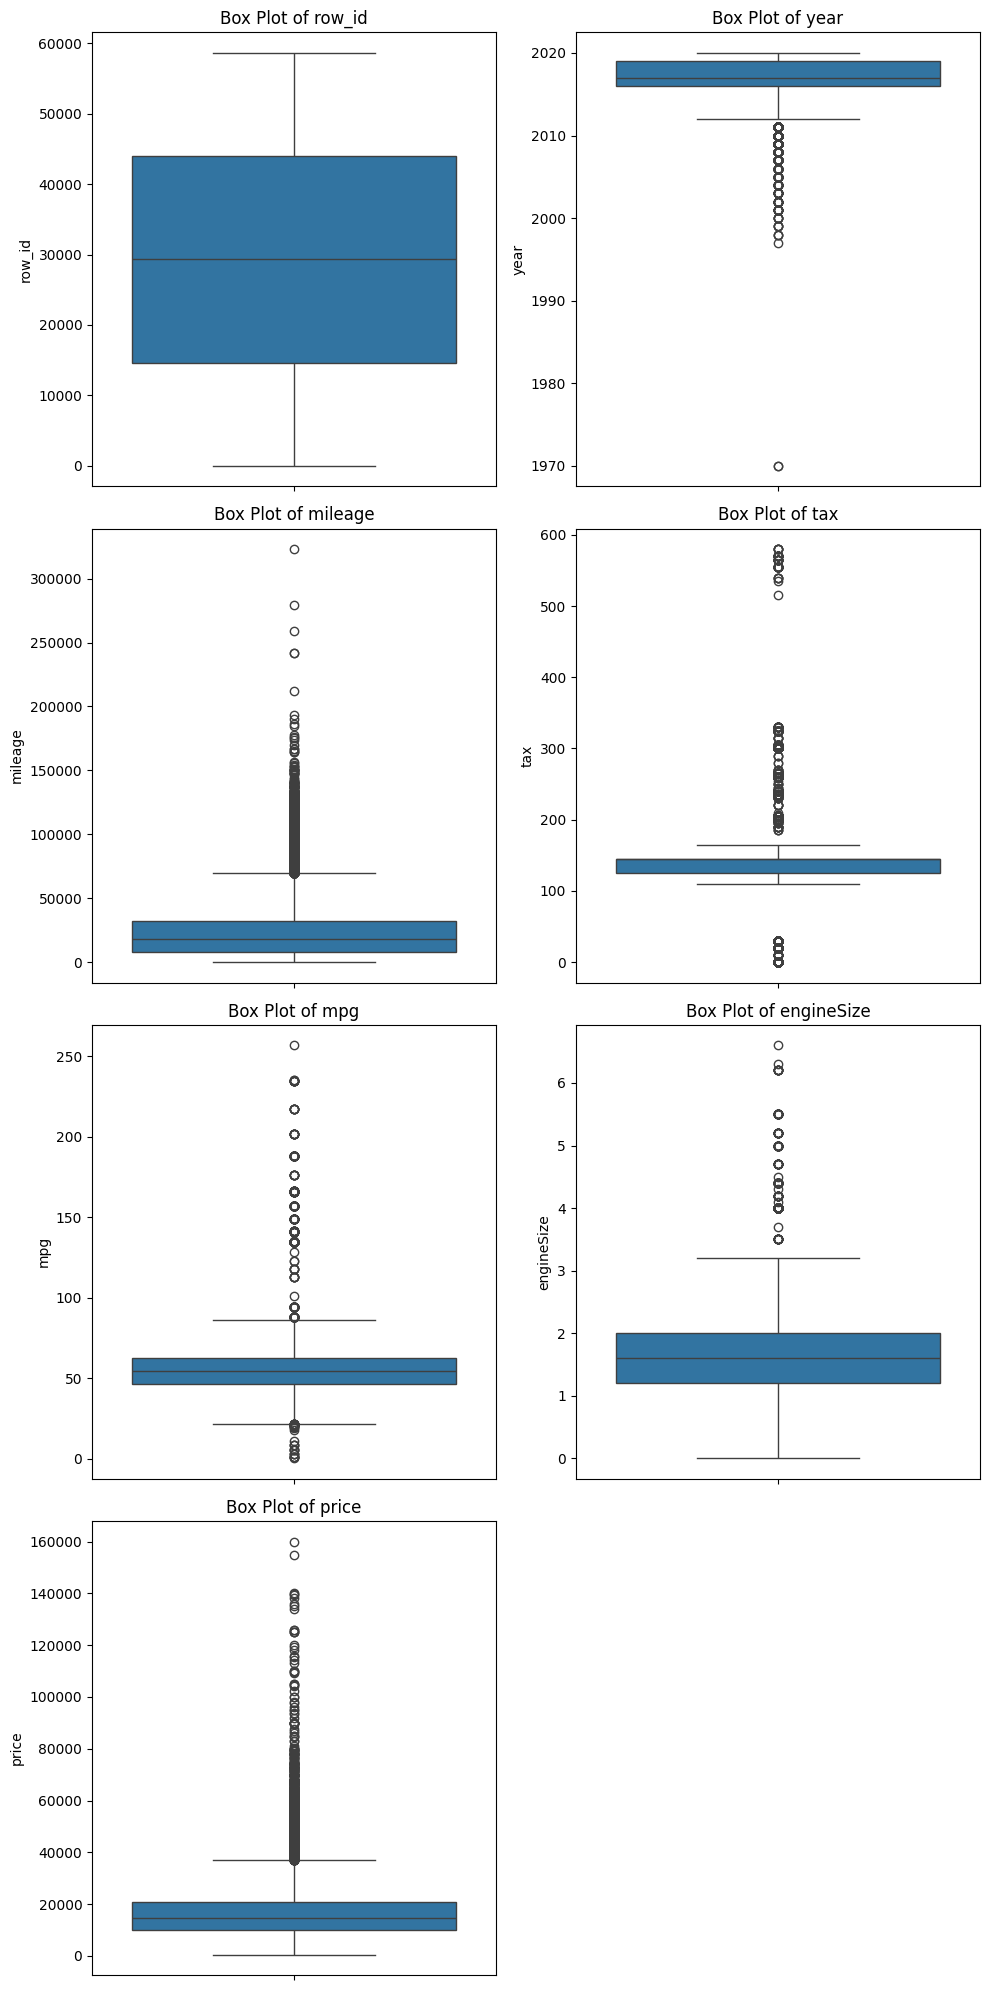

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identify numerical columns
numerical_cols = train.select_dtypes(include=np.number).columns

# Determine the number of rows and columns for subplots
n_cols = 2 # Number of columns for subplots
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Calculate number of rows needed

# Plot box plots for each numerical column
plt.figure(figsize=(10, n_rows * 5)) # Adjust figure size for vertical plots
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=train[col]) # Change to y for vertical orientation
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col) # Change xlabel to ylabel

plt.tight_layout()
plt.show()

#이상치 처리(year)

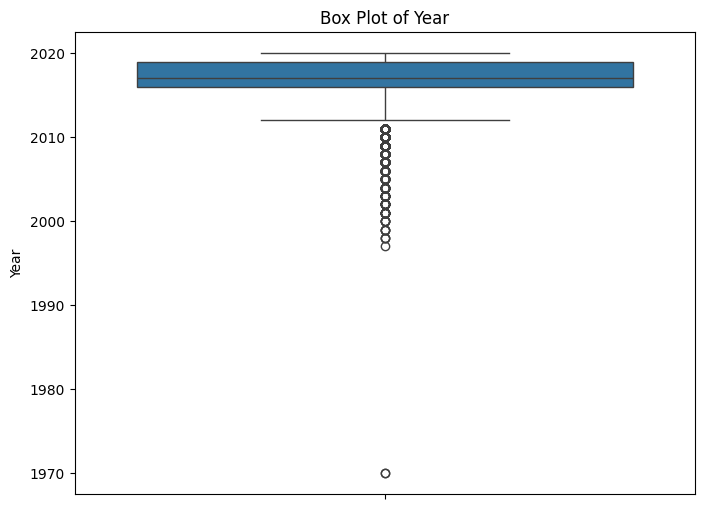

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=train['year'])
plt.title('Box Plot of Year')
plt.ylabel('Year')
plt.show()

In [18]:
# 1997년 미만인 'year' 값을 가진 행 필터링 및 출력
print("'year' 값이 1997년 미만인 행 (제거 예정):")
year_below_1997 = train[train['year'] < 1997]
display(year_below_1997)

# 'year' 값이 1997년 미만인 행 제거
initial_rows = len(train)
train = train[train['year'] >= 1997].reset_index(drop=True)
removed_rows = initial_rows - len(train)

print(f"\n'year' 값이 1997년 미만인 행 {removed_rows}개가 제거되었습니다.")

# 제거 후 'year' 값의 최소값 확인 (1997 이상이어야 함)
print("제거 후 'year'의 최소값:", train['year'].min())

# 제거 후 1997년 미만의 'year' 값이 없는지 확인
print("제거 후 'year' 값이 1997년 미만인 행의 수:", train[train['year'] < 1997].shape[0])

'year' 값이 1997년 미만인 행 (제거 예정):


,row_id,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price,original_fuelType,suggested_fuelType_ym,fuelType_filled,fill_source
18945,18945,vauxhall,Zafira,1970,Manual,37357.0,Petrol,145.0,42.2,1.4,10495,Petrol,Petrol,Petrol,original
54861,54861,merc,M Class,1970,Automatic,14000.0,Diesel,305.0,39.2,0.0,24999,Diesel,Diesel,Diesel,original



'year' 값이 1997년 미만인 행 2개가 제거되었습니다.
제거 후 'year'의 최소값: 1997
제거 후 'year' 값이 1997년 미만인 행의 수: 0


# 이상치 처리(mpg)

In [19]:
# Identify rows where mpg was originally less than 11
rows_affected_by_clipping = train[train['mpg'] <= 11]

# Apply clipping to the 'mpg' column: replace values less than 11 with 11
train['mpg'] = train['mpg'].clip(lower=11)

# Display the rows that were affected to show the change in 'mpg'
print("Rows where 'mpg' was originally less than 11 (after clipping):")
display(train.loc[rows_affected_by_clipping.index])

# Verify the changes (optional) - check the minimum value of mpg
print("\nMinimum value of mpg after clipping:", train['mpg'].min())

Rows where 'mpg' was originally less than 11 (after clipping):


,row_id,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price,original_fuelType,suggested_fuelType_ym,fuelType_filled,fill_source
204,204,hyundi,Ioniq,2020,Automatic,4152.0,Hybrid,135.0,11.0,1.6,23895,Hybrid,Hybrid,Hybrid,original
7563,7563,bmw,X3,2020,Semi-Auto,2000.0,Hybrid,135.0,11.0,2.0,53995,Hybrid,Diesel,Hybrid,original
11229,11229,bmw,3 Series,2019,Semi-Auto,4953.0,Hybrid,135.0,11.0,2.0,33995,Hybrid,Diesel,Hybrid,original
11844,11844,toyota,C-HR,2018,Manual,16429.0,Petrol,145.0,11.0,1.2,16690,Petrol,Hybrid,Petrol,original
15334,15334,toyota,Hilux,2020,Automatic,150.0,Diesel,260.0,11.0,2.4,36995,Diesel,Diesel,Diesel,original
24179,24180,toyota,Hilux,2020,Automatic,5000.0,Diesel,260.0,11.0,2.4,30500,Diesel,Diesel,Diesel,original
26100,26101,toyota,Hilux,2019,Automatic,10250.0,Diesel,260.0,11.0,2.4,27850,Diesel,Diesel,Diesel,original
28365,28366,bmw,3 Series,2019,Semi-Auto,4602.0,Hybrid,135.0,11.0,2.0,35230,Hybrid,Diesel,Hybrid,original
32225,32226,merc,A Class,2020,Semi-Auto,1000.0,Hybrid,135.0,11.0,1.3,31500,Hybrid,Petrol,Hybrid,original
37503,37504,bmw,X3,2020,Semi-Auto,1385.0,Hybrid,135.0,11.0,2.0,47000,Hybrid,Diesel,Hybrid,original



Minimum value of mpg after clipping: 11.0


#이상치 처리(tax)

In [20]:
# 2018년 이후에 세금이 0인 행 필터링
tax_zero_after_2018 = train[
    (train['year'] >= 2018) &
    (train['tax'] == 0)
]

# 필터링된 행 보여주기
print("2018년 이후 데이터에서 세금이 0인 행:")
display(tax_zero_after_2018)

# 해당 행 개수 확인 (선택 사항)
print(f"\n2018년 이후 데이터에서 세금이 0인 행의 개수: {len(tax_zero_after_2018)}")

2018년 이후 데이터에서 세금이 0인 행:


,row_id,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price,original_fuelType,suggested_fuelType_ym,fuelType_filled,fill_source
54292,54293,vauxhall,Astra,2018,Manual,17863.0,Petrol,0.0,74.3,1.4,10998,Petrol,Petrol,Petrol,original



2018년 이후 데이터에서 세금이 0인 행의 개수: 1


In [21]:
# 2018년 이후에 세금이 0인 행 필터링
condition_tax_zero_after_2018 = (
    (train['year'] >= 2018) &
    (train['tax'] == 0)
)

# 해당 행의 인덱스 가져오기
indices_to_impute_tax_zero = train.loc[condition_tax_zero_after_2018].index

if not indices_to_impute_tax_zero.empty:
    print(f"Info: {len(indices_to_impute_tax_zero)} rows with 'tax' == 0 after 2018 will be imputed.")

    # 1) fuelType별 tax 중앙값 (0은 제외하고 계산)
    fueltype_tax_median = (
        train[train['tax'] > 0]
        .groupby('fuelType')['tax']
        .median())
    # 2) (옵션) 전체 중앙값 - fuelType별 중앙값이 없는 경우 대비
    global_tax_median = train.loc[train['tax'] > 0, 'tax'].median()

    for idx in indices_to_impute_tax_zero:
        current_fuel_type = train.loc[idx, 'fuelType']
        # fuelType별 중앙값을 사용하고, 없으면 전체 중앙값(global_tax_median)을 사용
        imputed_tax_value = fueltype_tax_median.get(current_fuel_type, global_tax_median)
        train.loc[idx, 'tax'] = imputed_tax_value

    print("Imputation for 'tax' == 0 after 2018 completed.")

# 'tax' 0인 행이 남아있는지 확인
print("Number of rows in train after imputing tax 0 after 2018:", len(train))
print("Checking for tax 0 after 2018 in train:", train[(train['year'] >= 2018) & (train['tax'] == 0)].shape[0])

Info: 1 rows with 'tax' == 0 after 2018 will be imputed.
Imputation for 'tax' == 0 after 2018 completed.
Number of rows in train after imputing tax 0 after 2018: 58625
Checking for tax 0 after 2018 in train: 0


In [22]:
# 2018년 이전에 세금이 0인 행 필터링
tax_zero_before_2018 = train[
    (train['year'] < 2018) &
    (train['tax'] == 0)
]

# 필터링된 행 보여주기
print("2018년 이전에 세금이 0인 행:")
display(tax_zero_before_2018)

# 해당 행 개수 확인 (선택 사항)
print(f"\n2018년 이전에 세금이 0인 행의 개수: {len(tax_zero_before_2018)}")

2018년 이전에 세금이 0인 행:


,row_id,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price,original_fuelType,suggested_fuelType_ym,fuelType_filled,fill_source
12,12,toyota,C-HR,2017,Automatic,13315.0,Hybrid,0.0,74.3,1.8,21388,Hybrid,Hybrid,Hybrid,original
14,14,ford,Fiesta,2015,Manual,28000.0,Diesel,0.0,88.3,1.5,6990,Diesel,Petrol,Diesel,original
46,46,audi,A3,2015,Manual,68446.0,Diesel,0.0,74.3,1.6,8199,Diesel,Diesel,Diesel,original
51,51,toyota,Aygo,2017,Manual,10262.0,Petrol,0.0,68.9,1.0,7695,Petrol,Petrol,Petrol,original
54,54,ford,Fiesta,2017,Manual,15296.0,Petrol,0.0,65.7,1.0,10500,Petrol,Petrol,Petrol,original
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58564,58566,ford,Fiesta,2017,Manual,24282.0,Petrol,0.0,65.7,1.0,8995,Petrol,Petrol,Petrol,original
58566,58568,toyota,Auris,2015,Automatic,34500.0,Hybrid,0.0,72.4,1.8,12795,Hybrid,Hybrid,Hybrid,original
58581,58583,audi,A3,2016,Manual,59800.0,Diesel,0.0,74.3,1.6,10495,Diesel,Petrol,Diesel,original
58591,58593,bmw,3 Series,2016,Automatic,29789.0,Hybrid,0.0,134.5,2.0,19499,Hybrid,Diesel,Hybrid,original



2018년 이전에 세금이 0인 행의 개수: 3435


#이상치 처리(engine size)

In [23]:
# engineSize가 0인 행 필터링
engine_size_zero_rows = train[train['engineSize'] == 0.0]

# engineSize가 0인 행 보여주기
print("'engineSize' 값이 0인 행:")
display(engine_size_zero_rows)

# engineSize가 0인 행들 중에서 fuelType이 Electric인 행 필터링
electric_zero_engine = engine_size_zero_rows[engine_size_zero_rows['fuelType'] == 'Electric']

# fuelType이 Electric인 engineSize 0 행 보여주기
print("\n'engineSize' 값이 0이고 'fuelType'이 Electric인 행:")
display(electric_zero_engine)

'engineSize' 값이 0인 행:


,row_id,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price,original_fuelType,suggested_fuelType_ym,fuelType_filled,fill_source
525,525,hyundi,IX35,2015,Manual,26564.0,Petrol,200.0,41.5,0.0,9700,Petrol,Diesel,Petrol,original
531,531,audi,Q2,2019,Manual,1076.0,Petrol,145.0,40.9,0.0,23888,Petrol,Petrol,Petrol,original
696,696,audi,A3,2005,Manual,122000.0,Diesel,150.0,53.3,0.0,2495,Diesel,Diesel,Diesel,original
865,865,audi,Q3,2020,Automatic,1500.0,Petrol,145.0,30.7,0.0,38888,Petrol,Petrol,Petrol,original
983,983,merc,A Class,2016,Automatic,29712.0,Diesel,20.0,68.9,0.0,17500,Diesel,Diesel,Diesel,original
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55816,55818,audi,TT,2017,Automatic,27607.0,Petrol,200.0,40.9,0.0,27000,Petrol,Petrol,Petrol,original
57496,57498,ford,Fiesta,2018,Manual,23000.0,Petrol,150.0,65.7,0.0,11325,Petrol,Petrol,Petrol,original
57594,57596,ford,Focus,2017,Manual,11000.0,Petrol,145.0,51.4,0.0,12975,Petrol,Petrol,Petrol,original
58112,58114,vauxhall,Insignia,2017,Manual,36595.0,Petrol,145.0,47.1,0.0,13000,Petrol,Diesel,Petrol,original



'engineSize' 값이 0이고 'fuelType'이 Electric인 행:


,row_id,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price,original_fuelType,suggested_fuelType_ym,fuelType_filled,fill_source
10385,10385,bmw,i3,2016,Automatic,9990.0,Electric,0.0,39.0,0.0,18999,Electric,Hybrid,Electric,original
39663,39664,bmw,i3,2017,Automatic,20321.0,Electric,135.0,39.0,0.0,18999,Electric,Hybrid,Electric,original


In [24]:
# Identify rows where engineSize is 0.0 and fuelType is not 'Electric'
condition_to_impute = (train['engineSize'] == 0.0) & (train['fuelType'] != 'Electric')
rows_to_impute_indices = train.loc[condition_to_impute].index

# Calculate the mode of 'engineSize' for each year and model group, excluding engineSize 0.0 values from the calculation
# We calculate mode from rows where engineSize is NOT 0
engine_size_mode_by_year_model = (
    train[train['engineSize'] != 0.0]
    .groupby(['year', 'model'])['engineSize']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'engineSize': 'suggested_engineSize'})
)

# Merge suggested engine size back to the original train DataFrame
# This merge will bring the suggested_engineSize for rows where year and model match
train = train.merge(engine_size_mode_by_year_model, on=['year', 'model'], how='left')

# Impute engineSize 0.0 values based on the condition_to_impute using the suggested_engineSize
# Ensure suggested_engineSize is not None before imputing
for index in rows_to_impute_indices:
    suggested_value = train.loc[index, 'suggested_engineSize']
    if pd.notnull(suggested_value):
        train.loc[index, 'engineSize'] = suggested_value

# Drop the temporary suggested_engineSize column
train = train.drop('suggested_engineSize', axis=1)

# Verify the changes (optional)
print("'engineSize'가 0인 행들 중 전기차 제외하고 대체 후 'engineSize' 분포:")
display(train[condition_to_impute]['engineSize'].value_counts(dropna=False))

print("\n남아있는 'engineSize' 0 값 개수:")
display(train[train['engineSize'] == 0.0].shape[0])

'engineSize'가 0인 행들 중 전기차 제외하고 대체 후 'engineSize' 분포:


,count
engineSize,
2.0,39
1.0,33
0.6,23
1.4,16
1.5,15
1.2,9
0.0,6
1.6,6
1.7,3



남아있는 'engineSize' 0 값 개수:


8

In [25]:
# Identify rows to be removed: engineSize is 0.0 AND fuelType is NOT 'Electric'
rows_to_remove = train[
    (train['engineSize'] == 0.0) &
    (train['fuelType'] != 'Electric')
]

# Get the indices of these rows
indices_to_remove = rows_to_remove.index

# Drop the identified rows from the train DataFrame
train = train.drop(indices_to_remove).reset_index(drop=True)

# Verify the deletion (optional)
print("Number of rows in train after removing non-electric engineSize 0.0 outliers:", len(train))
print("Checking for non-electric engineSize 0.0 rows:", train[(train['engineSize'] == 0.0) & (train['fuelType'] != 'Electric')].shape[0])
print("Checking for electric engineSize 0.0 rows:", train[(train['engineSize'] == 0.0) & (train['fuelType'] == 'Electric')].shape[0])

Number of rows in train after removing non-electric engineSize 0.0 outliers: 58619
Checking for non-electric engineSize 0.0 rows: 0
Checking for electric engineSize 0.0 rows: 2


In [26]:
remaining_zero_engine_size_rows = train[train['engineSize'] == 0.0]
display(remaining_zero_engine_size_rows)

,row_id,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price,original_fuelType,suggested_fuelType_ym,fuelType_filled,fill_source
10384,10385,bmw,i3,2016,Automatic,9990.0,Electric,0.0,39.0,0.0,18999,Electric,Hybrid,Electric,original
39657,39664,bmw,i3,2017,Automatic,20321.0,Electric,135.0,39.0,0.0,18999,Electric,Hybrid,Electric,original


#이상치 처리(price)

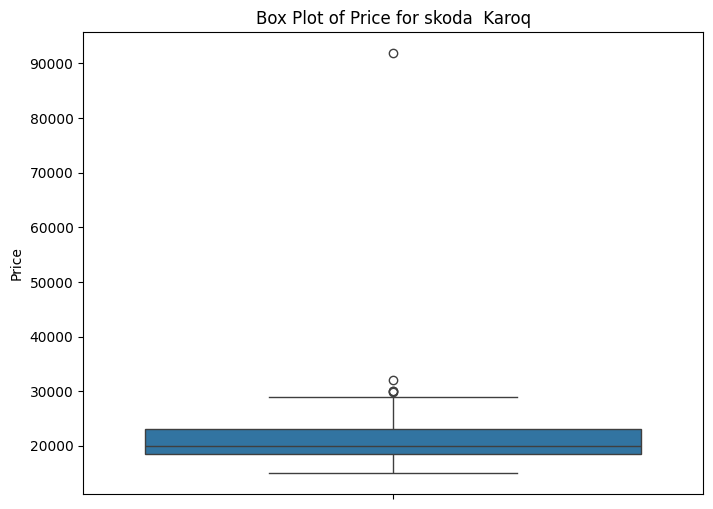

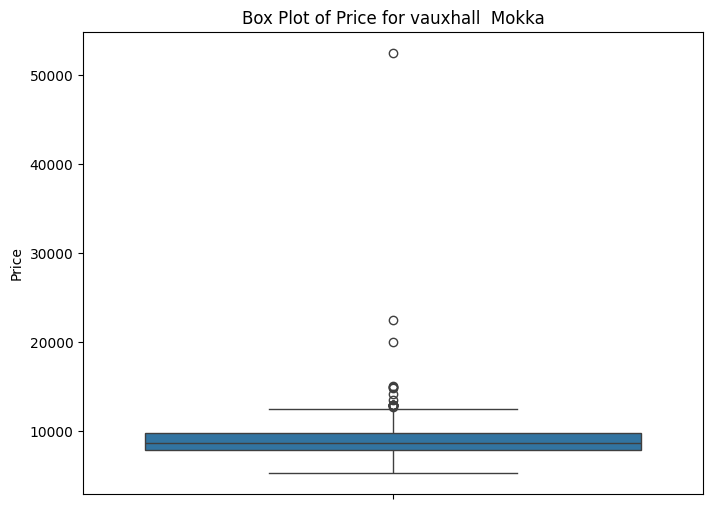

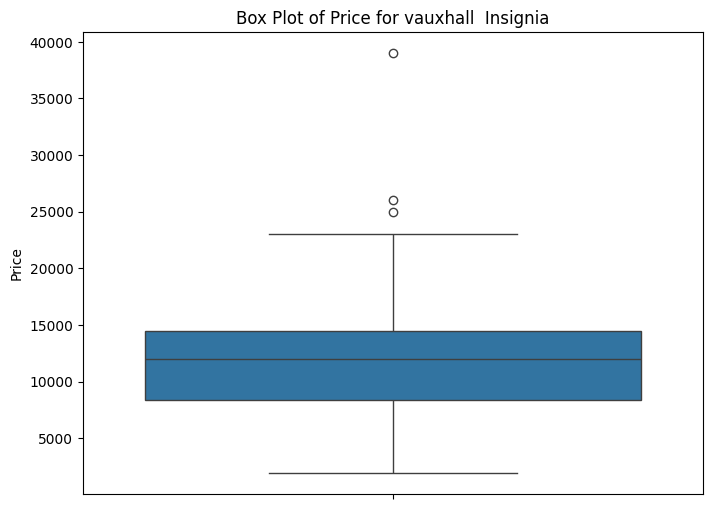

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the specific models to plot
models_to_plot = [
    {'brand': 'skoda', 'model': ' Karoq'},
    {'brand': 'vauxhall', 'model': ' Mokka'},
    {'brand': 'vauxhall', 'model': ' Insignia'}
]

for item in models_to_plot:
    brand = item['brand']
    model = item['model']

    # Filter the DataFrame for the specific brand and model
    filtered_data = train[(train['brand'] == brand) & (train['model'] == model)]

    if not filtered_data.empty:
        plt.figure(figsize=(8, 6))
        sns.boxplot(y=filtered_data['price'])
        plt.title(f'Box Plot of Price for {brand} {model}')
        plt.ylabel('Price')
        plt.show()
    else:
        print(f"No data found for {brand} {model}")

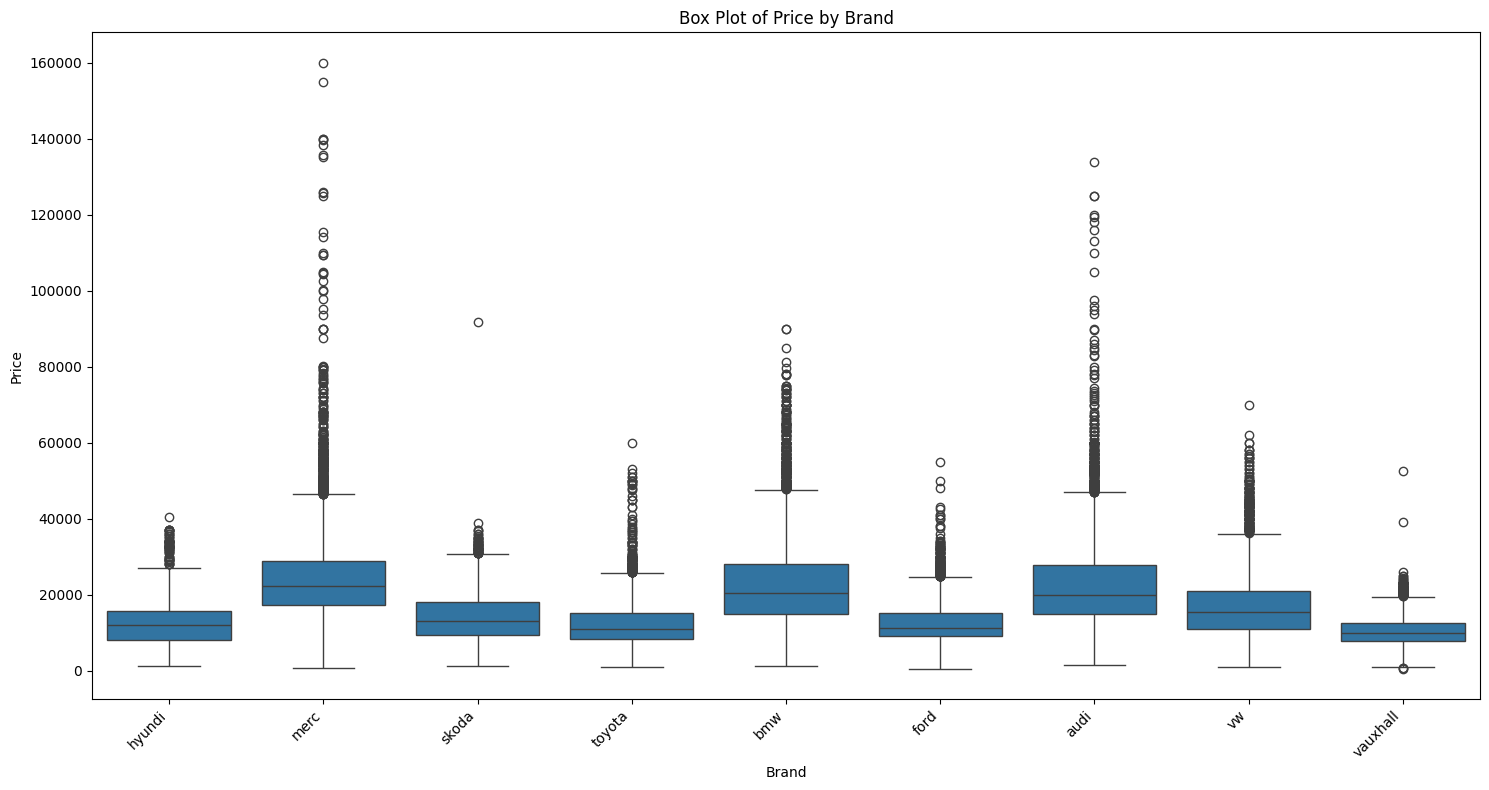

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot of price by brand
plt.figure(figsize=(15, 8)) # Adjust figure size for better readability
sns.boxplot(data=train, x='brand', y='price')
plt.title('Box Plot of Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

In [29]:
# Define the outlier treatment rules for price
price_outlier_rules = [
    {'brand': 'skoda', 'model': ' Karoq'}, # Added leading space
    {'brand': 'vauxhall', 'model': ' Mokka'}, # Added leading space
    {'brand': 'vauxhall', 'model': ' Insignia'} # Added rule for Vauxhall Insignia
]

# Apply the outlier treatment for each rule
for rule in price_outlier_rules:
    brand = rule['brand']
    model = rule['model']

    # Filter data for the specific brand and model
    model_data = train[(train['brand'] == brand) & (train['model'] == model)].copy()

    # Sort by price in descending order
    sorted_model_data = model_data.sort_values(by='price', ascending=False)

    # Check if there are at least two unique prices to perform the replacement
    unique_prices = sorted_model_data['price'].unique()

    if len(unique_prices) >= 2:
        highest_price = unique_prices[0]
        second_highest_price = unique_prices[1]

        # Identify the index of the row(s) with the highest price in the original train DataFrame
        indices_to_replace = train[(train['brand'] == brand) & (train['model'] == model) & (train['price'] == highest_price)].index

        # Replace the highest price with the second highest price in the original train DataFrame
        train.loc[indices_to_replace, 'price'] = second_highest_price

        print(f"{brand} {model}: Highest price ({highest_price}) replaced with second highest price ({second_highest_price}).")
    elif len(unique_prices) == 1:
         print(f"{brand} {model}: Only one unique price found. No replacement needed for highest price.")
    else:
        print(f"{brand} {model}: No price data found.")


# Verify the changes (optional) - You can display rows with the second highest price for these models if needed
# Example verification for Skoda Karoq (optional)
# print("\nChecking prices for Skoda Karoq after outlier treatment:")
# display(train[(train['brand'] == 'skoda') & (train['model'] == ' Karoq')].sort_values(by='price', ascending=False))

skoda  Karoq: Highest price (91874) replaced with second highest price (31990).
vauxhall  Mokka: Highest price (52489) replaced with second highest price (22499).
vauxhall  Insignia: Highest price (39000) replaced with second highest price (25999).


# 중복되는 행 제거

In [30]:
# 중복되는 행 확인 및 제거
initial_rows = len(train)

# 중복되는 행 식별 (첫 번째 발생 행 제외)
duplicate_rows = train[train.duplicated(keep=False)]

if not duplicate_rows.empty:
    print("### 중복되는 행(전체 열 기준):")
    display(duplicate_rows.sort_values(by=list(train.columns)))
    print(f"총 {len(duplicate_rows)}개의 중복 행이 발견되었습니다.\n")

    # 중복되는 행 제거 (첫 번째 발생 행은 남기고 나머지 제거)
    train = train.drop_duplicates(keep='first').reset_index(drop=True)
    removed_rows = initial_rows - len(train)
    print(f"중복되는 행 {removed_rows}개 삭제 후 train 데이터의 행 수: {len(train)}")
else:
    print("### 현재 train 데이터프레임에 중복되는 행이 없습니다.")
    removed_rows = 0

# 최종 확인
print("train 데이터에서 중복되는 행 확인 (삭제 후):", train[train.duplicated()].shape[0])

### 현재 train 데이터프레임에 중복되는 행이 없습니다.
train 데이터에서 중복되는 행 확인 (삭제 후): 0


# 인코딩

In [31]:
brand_model = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/IBA_REG/brand_model.csv")

In [32]:
from sklearn.model_selection import train_test_split

# 1. Create X by dropping the 'price' column from the train DataFrame and y with the 'price' column from the train DataFrame.
X = train.drop('price', axis=1)
y = train['price']

# 2. Split X and y into X_train_raw, X_val_raw, y_train, and y_val using train_test_split with test_size=0.2 and random_state=42.
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train_raw shape:", X_train_raw.shape)
print("X_val_raw shape:", X_val_raw.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

# Store required imputation values from the *processed* train set
# Mileage medians
mileage_median_by_year_model_train_map = train.groupby(['year', 'model'])['mileage'].median()
mileage_median_by_year_train_map = train.groupby('year')['mileage'].median()
mileage_median_overall_train = train['mileage'].median()

# Mpg medians
mpg_median_by_year_model_fuel_train_map = train.groupby(['year', 'model', 'fuelType'])['mpg'].median()
mpg_median_by_year_model_train_map = train.groupby(['year', 'model'])['mpg'].median()
mpg_median_by_model_train_map = train.groupby('model')['mpg'].median()
mpg_median_by_fuelType_train_map = train.groupby('fuelType')['mpg'].median() # Added this line

# Tax medians
tax_median_by_year_model_fuel_train_map = train.groupby(['year', 'model', 'fuelType'])['tax'].median()
tax_median_by_year_model_train_map = train.groupby(['year', 'model'])['tax'].median()
tax_median_by_model_train_map = train.groupby('model')['tax'].median()
tax_median_by_fuelType_train_map = train.groupby('fuelType')['tax'].median()

# Mode for transmission 'Other' (by brand/model, existing)
# mode_trans is already available as a global from previous cells

# Mode for transmission 'Other' by year and model (newly added)
mode_trans_by_year_model_train_map = (
    train[train['transmission'] != 'Other']
    .groupby(['year', 'model'])['transmission']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'transmission': 'suggested_transmission_year_model'})
)

# Mode for transmission 'Other' by model (existing)
mode_trans_by_model_train_map = (
    train[train['transmission'] != 'Other']
    .groupby('model')['transmission']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'transmission': 'suggested_transmission_model'})
)

# Modes for fuelType 'Other' (already computed in dQQ2MWgA6ocf, using its latest state)
fuel_type_mode_by_year_model = (
    train[train['fuelType'] != 'Other']
    .groupby(['year', 'model'])['fuelType']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'fuelType': 'suggested_fuelType_ym'})
)

# (model) 기준으로 'Other' 제외 fuelType 최빈값
fuel_type_mode_by_model = (
    train[train['fuelType'] != 'Other']
    .groupby(['model'])['fuelType']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'fuelType': 'suggested_fuelType_m'})
)

# Mode for engineSize 0.0 imputation (already computed in tKIQt1crJp-t, using its latest state)
# engine_size_mode_by_year_model is already available as a global

# Mode for engineSize 0.0 imputation by model (newly added)
engine_size_mode_by_model_train_map = (
    train[train['engineSize'] != 0.0]
    .groupby('model')['engineSize']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'engineSize': 'suggested_engineSize_model'})
)

# Median engineSize for Diesel/Petrol cars for fallback imputation (newly added)
engine_size_median_diesel_petrol_train_map = train[
    (train['engineSize'] != 0.0) & (train['fuelType'].isin(['Diesel', 'Petrol']))
]['engineSize'].median()


X_train_raw shape: (46895, 14)
X_val_raw shape: (11724, 14)
y_train shape: (46895,)
y_val shape: (11724,)


In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# Create a copy of the original test data to preserve 'id' for submission
test_processed = test.copy()

# --- Apply preprocessing steps to test_processed ---

# 1. Mileage Imputation (using train statistics)
# Apply year and model-specific median
test_processed['mileage'] = test_processed.groupby(['year', 'model'])['mileage'].transform(lambda x: x.fillna(mileage_median_by_year_model_train_map.get((x.name[0], x.name[1]), mileage_median_overall_train)))

# Apply year-specific median for remaining NaNs
test_processed['mileage'] = test_processed.groupby('year')['mileage'].transform(lambda x: x.fillna(mileage_median_by_year_train_map.get(x.name, mileage_median_overall_train)))

# Fill any remaining NaNs with overall train median
test_processed['mileage'] = test_processed['mileage'].fillna(mileage_median_overall_train)

# 7. MPG domain-specific outlier handling and clipping
i3_model_rows_indices_test = test_processed[test_processed['model'] == ' i3'].index
test_processed.loc[i3_model_rows_indices_test, 'mpg'] = 39

# First, handle specific rule: 'Other' and mpg >= 100 -> 'Hybrid'
condition_replace_other_to_hybrid_test = (test_processed['fuelType'] == 'Other') & (test_processed['mpg'] >= 100)
test_processed.loc[condition_replace_other_to_hybrid_test, 'fuelType'] = 'Hybrid'

# 5. FuelType 'Other' handling (mirroring train data)


# First general imputation step: year/model-based mode imputation
temp_fuel_type_mode_ym = fuel_type_mode_by_year_model.rename(columns={'suggested_fuelType_ym': 'suggested_fuelType_ym_test'})
test_processed = test_processed.merge(temp_fuel_type_mode_ym, on=['year', 'model'], how='left')
test_processed['fuelType'] = test_processed.apply(
    lambda row: row['suggested_fuelType_ym_test'] if row['fuelType'] == 'Other' and pd.notnull(row['suggested_fuelType_ym_test'])
    else row['fuelType'],
    axis=1
)
test_processed = test_processed.drop('suggested_fuelType_ym_test', axis=1)

# Second general imputation step: model-based mode imputation (for cases where year/model didn't provide a mode)
temp_fuel_type_mode_m = fuel_type_mode_by_model.rename(columns={'suggested_fuelType_m': 'suggested_fuelType_m_test'})
test_processed = test_processed.merge(temp_fuel_type_mode_m, on='model', how='left')
test_processed['fuelType'] = test_processed.apply(
    lambda row: row['suggested_fuelType_m_test'] if row['fuelType'] == 'Other' and pd.notnull(row['suggested_fuelType_m_test'])
    else row['fuelType'],
    axis=1
)
test_processed = test_processed.drop('suggested_fuelType_m_test', axis=1)


# Third imputation step: mileage-based imputation for remaining 'Other' fuelTypes
remaining_other_fuel_indices_test = test_processed[test_processed['fuelType'] == 'Other'].index

if not remaining_other_fuel_indices_test.empty:
    non_other_fuel_df_test = test_processed[test_processed['fuelType'] != 'Other'][['fuelType', 'mileage']].copy()

    if not non_other_fuel_df_test.empty:
        for idx in remaining_other_fuel_indices_test:
            target_mileage_test = test_processed.loc[idx, 'mileage']

            non_other_fuel_df_test['mileage'] = pd.to_numeric(non_other_fuel_df_test['mileage'], errors='coerce')
            non_other_fuel_clean_test = non_other_fuel_df_test.dropna(subset=['mileage'])

            if not non_other_fuel_clean_test.empty:
                abs_diff_mileage_test = (non_other_fuel_clean_test['mileage'] - target_mileage_test).abs()
                closest_row_idx_in_non_other_test = abs_diff_mileage_test.idxmin()
                imputed_fuel_type_test = non_other_fuel_clean_test.loc[closest_row_idx_in_non_other_test, 'fuelType']
                test_processed.loc[idx, 'fuelType'] = imputed_fuel_type_test

# Final removal step: Remove any persistently 'Other' fuelType rows
final_other_fuel_type_rows_test = test_processed[test_processed['fuelType'] == 'Other']
if not final_other_fuel_type_rows_test.empty:
    test_processed = test_processed.drop(final_other_fuel_type_rows_test.index).reset_index(drop=True)

# 2. MPG Imputation (using train statistics)
test_processed['mpg'] = pd.to_numeric(test_processed['mpg'], errors='coerce')

# Apply year, model, fuelType-specific median
test_processed['mpg'] = test_processed.groupby(['year', 'model', 'fuelType'])['mpg'].transform(lambda x: x.fillna(mpg_median_by_year_model_fuel_train_map.get((x.name[0], x.name[1], x.name[2]), 35.3)))

# Apply year, model-specific median
test_processed['mpg'] = test_processed.groupby(['year', 'model'])['mpg'].transform(lambda x: x.fillna(mpg_median_by_year_model_train_map.get((x.name[0], x.name[1]), 35.3)))

# Apply model-specific median
test_processed['mpg'] = test_processed.groupby('model')['mpg'].transform(lambda x: x.fillna(mpg_median_by_model_train_map.get(x.name, 35.3)))

# Apply fuelType-specific median for remaining NaNs (new step)
test_processed['mpg'] = test_processed.groupby('fuelType')['mpg'].transform(lambda x: x.fillna(mpg_median_by_fuelType_train_map.get(x.name, 35.3)))

# 3. Tax Imputation (using train statistics)
# Apply year, model, fuelType-specific median
test_processed['tax'] = test_processed.groupby(['year', 'model', 'fuelType'])['tax'].transform(lambda x: x.fillna(tax_median_by_year_model_fuel_train_map.get((x.name[0], x.name[1], x.name[2]), train['tax'].median())))

# Apply year, model-specific median
test_processed['tax'] = test_processed.groupby(['year', 'model'])['tax'].transform(lambda x: x.fillna(tax_median_by_year_model_train_map.get((x.name[0], x.name[1]), train['tax'].median())))

# Apply model-specific median
test_processed['tax'] = test_processed.groupby('model')['tax'].transform(lambda x: x.fillna(tax_median_by_model_train_map.get(x.name, train['tax'].median())))

# Apply fuelType-specific median for remaining NaNs
test_processed['tax'] = test_processed.groupby('fuelType')['tax'].transform(lambda x: x.fillna(tax_median_by_fuelType_train_map.get(x.name, train['tax'].median())))

# Fill remaining with overall train median
test_processed['tax'] = test_processed['tax'].fillna(train['tax'].median())

# Clip 'Diesel' or 'Petrol' mpg values >= 100 to the max valid mpg for that model/fuelType
condition_clip_diesel_petrol_mpg = (
    (test_processed['fuelType'].isin(['Diesel', 'Petrol'])) &
    (test_processed['mpg'] >= 100)
)

if not test_processed.loc[condition_clip_diesel_petrol_mpg].empty:
    max_valid_mpg_per_model_fuel_test = test_processed[
        (test_processed['mpg'] < 100) & (test_processed['fuelType'].isin(['Diesel', 'Petrol']))
    ].groupby(['model', 'fuelType'])['mpg'].max().reset_index()
    max_valid_mpg_per_model_fuel_test.rename(columns={'mpg': 'max_valid_mpg'}, inplace=True)

    # Perform a merge to get the max_valid_mpg for the rows that need clipping
    merged_clips = test_processed.loc[condition_clip_diesel_petrol_mpg].merge(
        max_valid_mpg_per_model_fuel_test,
        on=['model', 'fuelType'],
        how='left'
    )
    # Now, update the 'mpg' column in test_processed where 'max_valid_mpg' is not NaN
    # We use .loc and the index of 'merged_clips' to ensure correct alignment
    test_processed.loc[merged_clips[merged_clips['max_valid_mpg'].notna()].index, 'mpg'] = \
        merged_clips[merged_clips['max_valid_mpg'].notna()]['max_valid_mpg']


# 4. Transmission 'Other' handling (Three-step imputation + removal, mirroring train data)

# First imputation step: year/model-based mode imputation
temp_mode_trans_ym = mode_trans_by_year_model_train_map.rename(columns={'suggested_transmission_year_model': 'suggested_transmission_ym_test'})
test_processed = test_processed.merge(temp_mode_trans_ym, on=['year', 'model'], how='left')
test_processed['transmission'] = test_processed.apply(
    lambda row: row['suggested_transmission_ym_test'] if row['transmission'] == 'Other' and pd.notnull(row['suggested_transmission_ym_test'])
    else row['transmission'],
    axis=1
)
test_processed = test_processed.drop('suggested_transmission_ym_test', axis=1)

# Second imputation step: model-based mode imputation
temp_mode_trans_model = mode_trans_by_model_train_map.rename(columns={'suggested_transmission_model': 'suggested_transmission_model_test'})
test_processed = test_processed.merge(temp_mode_trans_model, on='model', how='left')
test_processed['transmission'] = test_processed.apply(
    lambda row: row['suggested_transmission_model_test'] if row['transmission'] == 'Other' and pd.notnull(row['suggested_transmission_model_test'])
    else row['transmission'],
    axis=1
)
test_processed = test_processed.drop('suggested_transmission_model_test', axis=1)

# Third Imputation Step: Impute remaining 'Other' transmissions based on closest mileage
remaining_other_indices_trans = test_processed[test_processed['transmission'] == 'Other'].index

if not remaining_other_indices_trans.empty:
    non_other_transmissions_df_test = test_processed[test_processed['transmission'] != 'Other'][['transmission', 'mileage']].copy()

    if not non_other_transmissions_df_test.empty:
        for idx in remaining_other_indices_trans:
            target_mileage_test = test_processed.loc[idx, 'mileage']

            # Calculate absolute difference between target_mileage and all non-Other mileages
            # Ensure 'mileage' column is numeric for comparison
            non_other_transmissions_df_test['mileage'] = pd.to_numeric(non_other_transmissions_df_test['mileage'], errors='coerce')
            non_other_transmissions_clean_test = non_other_transmissions_df_test.dropna(subset=['mileage'])

            if not non_other_transmissions_clean_test.empty:
                abs_diff_mileage_test = (non_other_transmissions_clean_test['mileage'] - target_mileage_test).abs()
                closest_row_idx_in_non_other_test = abs_diff_mileage_test.idxmin()
                imputed_transmission_test = non_other_transmissions_clean_test.loc[closest_row_idx_in_non_other_test, 'transmission']
                test_processed.loc[idx, 'transmission'] = imputed_transmission_test

# Final removal step: Remove any persistently 'Other' transmissions
final_other_transmission_indices_test = test_processed[test_processed['transmission'] == 'Other'].index
if not final_other_transmission_indices_test.empty:
    test_processed = test_processed.drop(final_other_transmission_indices_test).reset_index(drop=True)

# 6. Year Outlier Imputation (Sophisticated Logic - replaces simple clipping)
# Identify rows in test_processed where year < 1997 or year > 2025
outlier_indices = test_processed[(test_processed['year'] < 1997) | (test_processed['year'] > 2025)].index

# Create a DataFrame non_outlier_df containing rows from test_processed that are not identified as year outliers.
non_outlier_df = test_processed.drop(outlier_indices)

# Calculate the median year from non_outlier_df and store it as median_non_outlier_year.
median_non_outlier_year = non_outlier_df['year'].median()

# Iterate through each index in outlier_indices:
for idx in outlier_indices:
    # Retrieve the engineSize and mileage of the current outlier row.
    outlier_engine_size = test_processed.loc[idx, 'engineSize']
    outlier_mileage = test_processed.loc[idx, 'mileage']
    imputed_year = None

    # Filter non_outlier_df to find engine_size_matched_candidates where engineSize matches the outlier's engineSize.
    engine_size_matched_candidates = non_outlier_df[non_outlier_df['engineSize'] == outlier_engine_size]

    # If engine_size_matched_candidates is not empty:
    if not engine_size_matched_candidates.empty:
        # Calculate the lower and upper bounds for a +/- 5% mileage range around the outlier's mileage.
        lower_bound = outlier_mileage * 0.95
        upper_bound = outlier_mileage * 1.05

        # Filter engine_size_matched_candidates further to identify mileage_proximate_candidates within this 5% range.
        mileage_proximate_candidates = engine_size_matched_candidates[
            (engine_size_matched_candidates['mileage'] >= lower_bound) &
            (engine_size_matched_candidates['mileage'] <= upper_bound)
        ]

        # If mileage_proximate_candidates is not empty:
        if not mileage_proximate_candidates.empty:
            # calculate the absolute mileage difference for these candidates and select the year from the candidate with the minimum difference.
            diffs = (mileage_proximate_candidates['mileage'] - outlier_mileage).abs()
            imputed_year = mileage_proximate_candidates.loc[diffs.idxmin(), 'year']
        # Else (no mileage_proximate_candidates found but engine_size_matched_candidates is not empty):
        else:
            # calculate the absolute mileage difference for all engine_size_matched_candidates and select the year from the candidate with the minimum difference.
            diffs = (engine_size_matched_candidates['mileage'] - outlier_mileage).abs()
            imputed_year = engine_size_matched_candidates.loc[diffs.idxmin(), 'year']
    # Else (engine_size_matched_candidates is empty):
    else:
        # Calculate the absolute mileage difference between the outlier's mileage and all non_outlier_df rows.
        diffs = (non_outlier_df['mileage'] - outlier_mileage).abs()
        # Select the year from the non_outlier_df row with the minimum mileage difference.
        imputed_year = non_outlier_df.loc[diffs.idxmin(), 'year']

    # If no suitable candidate year was found through the above steps, use median_non_outlier_year for imputation.
    if imputed_year is None or pd.isna(imputed_year):
        imputed_year = median_non_outlier_year

    # Assign the determined imputed year value to the current outlier row in test_processed at the corresponding index.
    test_processed.loc[idx, 'year'] = imputed_year

test_processed['mpg'] = test_processed['mpg'].clip(lower=11)


# 8. Tax 0 after 2018 imputation (replacing removal)
condition_tax_zero_after_2018 = (test_processed['year'] >= 2018) & (test_processed['tax'] == 0)
indices_to_impute_tax_zero = test_processed.loc[condition_tax_zero_after_2018].index

if not indices_to_impute_tax_zero.empty:
    for idx in indices_to_impute_tax_zero:
        current_fuel_type = test_processed.loc[idx, 'fuelType']
        # Use a fallback to overall median if fuelType specific median is not found
        imputed_tax_value = tax_median_by_fuelType_train_map.get(current_fuel_type, train['tax'].median())
        test_processed.loc[idx, 'tax'] = imputed_tax_value


# 9. EngineSize 0.0 imputation and removal (using train statistics)
# Identify rows where engineSize is 0.0 and fuelType is not 'Electric' for imputation attempts
condition_to_impute_test = (test_processed['engineSize'] == 0.0) & (test_processed['fuelType'] != 'Electric')
rows_to_impute_indices_test = test_processed.loc[condition_to_impute_test].index

# First imputation attempt: year and model-based mode
temp_engine_size_modes_ym = engine_size_mode_by_year_model.rename(columns={'suggested_engineSize': 'suggested_engineSize_ym_test_impute'})
test_processed = test_processed.merge(temp_engine_size_modes_ym, on=['year', 'model'], how='left')

for index in rows_to_impute_indices_test:
    if index in test_processed.index: # Check if index still exists after previous removals
        suggested_value = test_processed.loc[index, 'suggested_engineSize_ym_test_impute']
        if pd.notnull(suggested_value):
            test_processed.loc[index, 'engineSize'] = suggested_value

test_processed = test_processed.drop('suggested_engineSize_ym_test_impute', axis=1)

# Second imputation attempt: model-based mode for remaining 0.0 values
remaining_zero_engine_size_indices_after_ym = test_processed[(test_processed['engineSize'] == 0.0) & (test_processed['fuelType'] != 'Electric')].index

temp_engine_size_modes_m = engine_size_mode_by_model_train_map.rename(columns={'suggested_engineSize_model': 'suggested_engineSize_m_test_impute'})
test_processed = test_processed.merge(temp_engine_size_modes_m, on='model', how='left')

for index in remaining_zero_engine_size_indices_after_ym:
    if index in test_processed.index: # Check if index still exists after previous removals
        suggested_value = test_processed.loc[index, 'suggested_engineSize_m_test_impute']
        if pd.notnull(suggested_value):
            test_processed.loc[index, 'engineSize'] = suggested_value

test_processed = test_processed.drop('suggested_engineSize_m_test_impute', axis=1)

# Third imputation attempt: Replace remaining 0.0 values with median of Diesel/Petrol engineSize
remaining_zero_engine_size_indices_before_median_imputation = test_processed[(test_processed['engineSize'] == 0.0) & (test_processed['fuelType'] != 'Electric')].index

if not remaining_zero_engine_size_indices_before_median_imputation.empty:
    for index in remaining_zero_engine_size_indices_before_median_imputation:
        test_processed.loc[index, 'engineSize'] = engine_size_median_diesel_petrol_train_map

# Remove engineSize 0.0 non-electric outliers that could not be imputed
rows_to_remove_engine_size_zero_test = test_processed[
    (test_processed['engineSize'] == 0.0) &
    (test_processed['fuelType'] != 'Electric')
]
test_processed = test_processed.drop(rows_to_remove_engine_size_zero_test.index).reset_index(drop=True)


# 10. Duplicate row removal
initial_rows_test = len(test_processed)
duplicate_rows_test = test_processed[test_processed.duplicated(keep=False)]
if not duplicate_rows_test.empty:
    test_processed = test_processed.drop_duplicates(keep='first').reset_index(drop=True)


# Prepare X_test_raw from the fully preprocessed test_processed DataFrame
X_test_raw = test_processed.drop('id', axis=1).copy()

print("Test data preprocessing completed. X_test_raw shape:", X_test_raw.shape)


Test data preprocessing completed. X_test_raw shape: (39085, 9)


In [34]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Define the categorical columns
categorical_cols = ['brand', 'model', 'transmission', 'fuelType']

# Create copies of the raw split data for one-hot encoding
X_train_ohe = X_train_raw.copy()
X_val_ohe = X_val_raw.copy()
X_test_ohe = X_test_raw.copy()

for feature in categorical_cols:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # Combine unique categories from brand_model and X_train_raw for fitting the encoder
    # Test data categories are intentionally excluded from fitting to prevent data leakage
    all_categories = []
    if feature in brand_model.columns:
        all_categories.extend(brand_model[feature].unique().tolist())
    all_categories.extend(X_train_raw[feature].unique().tolist())

    all_categories_df = pd.DataFrame(np.unique(all_categories).reshape(-1, 1), columns=[feature])

    ohe.fit(all_categories_df)

    # Transform and concatenate for X_train_ohe
    temp_train_encoded = ohe.transform(X_train_ohe[[feature]])
    feature_names = ohe.get_feature_names_out(input_features=[feature])
    temp_train_df = pd.DataFrame(temp_train_encoded, columns=feature_names, index=X_train_ohe.index)
    X_train_ohe = pd.concat([X_train_ohe.drop(feature, axis=1), temp_train_df], axis=1)

    # Transform and concatenate for X_val_ohe
    temp_val_encoded = ohe.transform(X_val_ohe[[feature]])
    feature_names = ohe.get_feature_names_out(input_features=[feature])
    temp_val_df = pd.DataFrame(temp_val_encoded, columns=feature_names, index=X_val_ohe.index)
    X_val_ohe = pd.concat([X_val_ohe.drop(feature, axis=1), temp_val_df], axis=1)

    # Transform and concatenate for X_test_ohe
    temp_test_encoded = ohe.transform(X_test_ohe[[feature]])
    feature_names = ohe.get_feature_names_out(input_features=[feature])
    temp_test_df = pd.DataFrame(temp_test_encoded, columns=feature_names, index=X_test_ohe.index)
    X_test_ohe = pd.concat([X_test_ohe.drop(feature, axis=1), temp_test_df], axis=1)

# One-Hot Encoding after imputation, fill any missing values (e.g., from handle_unknown='ignore' or imputation issues) with 0.
X_train_ohe.fillna(0, inplace=True)
X_val_ohe.fillna(0, inplace=True)
X_test_ohe.fillna(0, inplace=True)

# Ensure all columns are aligned across train, validation, and test datasets after OHE
# Get all unique column names from all three OHE dataframes
all_ohe_columns = sorted(list(set(X_train_ohe.columns) | set(X_val_ohe.columns) | set(X_test_ohe.columns)))

# Reindex all dataframes to have the same columns, filling new columns with 0
X_train_ohe = X_train_ohe.reindex(columns=all_ohe_columns, fill_value=0)
X_val_ohe = X_val_ohe.reindex(columns=all_ohe_columns, fill_value=0)
X_test_ohe = X_test_ohe.reindex(columns=all_ohe_columns, fill_value=0)

# Drop auxiliary object columns that are not intended as features
columns_to_drop = ['row_id', 'original_fuelType', 'suggested_fuelType_ym', 'fuelType_filled', 'fill_source']
X_train_ohe = X_train_ohe.drop(columns=[col for col in columns_to_drop if col in X_train_ohe.columns], axis=1)
X_val_ohe = X_val_ohe.drop(columns=[col for col in columns_to_drop if col in X_val_ohe.columns], axis=1)
X_test_ohe = X_test_ohe.drop(columns=[col for col in columns_to_drop if col in X_test_ohe.columns], axis=1)


print("One-hot encoding of split data completed.")
print(f"X_train_ohe shape: {X_train_ohe.shape}")
print(f"X_val_ohe shape: {X_val_ohe.shape}")
print(f"X_test_ohe shape: {X_test_ohe.shape}")

One-hot encoding of split data completed.
X_train_ohe shape: (46895, 216)
X_val_ohe shape: (11724, 216)
X_test_ohe shape: (39085, 216)


In [35]:
import xgboost as xgb

# Initialize XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror',
                        n_estimators=1500,
                        learning_rate=0.08,
                        max_depth=6,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        random_state=42,
                        n_jobs=-1,
                        enable_categorical=False, # Data is now one-hot encoded, so this should be False
                        tree_method='hist')

print("XGBoost model initialized with specified parameters.")

XGBoost model initialized with specified parameters.


In [36]:
xgbr = xgb_model

print("Model assigned to 'xgbr' variable.")

Model assigned to 'xgbr' variable.


In [37]:
print("XGBoost model training started...")
xgbr.fit(X_train_ohe, y_train)
print("XGBoost model training completed.")

XGBoost model training started...
XGBoost model training completed.


In [38]:
import numpy as np # np.sqrt를 위해 numpy를 임포트합니다。
from sklearn.metrics import mean_squared_error, r2_score

print("Making predictions on the validation set...")
y_pred_val_ohe = xgbr.predict(X_val_ohe)
print("Predictions completed.")

# Calculate RMSE and R^2
rmse_val_ohe = np.sqrt(mean_squared_error(y_val, y_pred_val_ohe))
r2_val_ohe = r2_score(y_val, y_pred_val_ohe)

print(f"\nValidation RMSE (XGBoost with OHE): {rmse_val_ohe:.4f}")
print(f"Validation R^2 Score (XGBoost with OHE): {r2_val_ohe:.4f}")

Making predictions on the validation set...
Predictions completed.

Validation RMSE (XGBoost with OHE): 1906.7001
Validation R^2 Score (XGBoost with OHE): 0.9638


lightgbm

In [39]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Initialize LightGBM Regressor model
lgbm_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=1600,
    learning_rate=0.1,
    num_leaves=31,  # default value
    max_depth=-1,   # no limit
    min_child_samples=20, # default value
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)

print("LightGBM model initialized with specified parameters.")

LightGBM model initialized with specified parameters.


In [40]:
print("LightGBM model training started...")
lgbm_model.fit(X_train_ohe.values, y_train.values)
print("LightGBM model training completed.")

LightGBM model training started...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004598 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 821
[LightGBM] [Info] Number of data points in the train set: 46895, number of used features: 154
[LightGBM] [Info] Start training from score 16752.842158
LightGBM model training completed.


In [41]:
print("Making predictions on the validation set...")
y_pred_val_lgbm = lgbm_model.predict(X_val_ohe.values)
print("Predictions completed.")

# Calculate RMSE and R^2
rmse_val_lgbm = np.sqrt(mean_squared_error(y_val, y_pred_val_lgbm))
r2_val_lgbm = r2_score(y_val, y_pred_val_lgbm)

print(f"\nValidation RMSE (LightGBM with OHE): {rmse_val_lgbm:.4f}")
print(f"Validation R^2 Score (LightGBM with OHE): {r2_val_lgbm:.4f}")

Making predictions on the validation set...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Predictions completed.

Validation RMSE (LightGBM with OHE): 2004.7511
Validation R^2 Score (LightGBM with OHE): 0.9600


결과저장

In [42]:
import pandas as pd
import numpy as np

# Define data_path (assuming it's in the same directory as the train/test files, or a known location)
data_path = "/content/drive/MyDrive/Colab Notebooks/IBA_REG" # Adjust this path if necessary

# 1. Make predictions on the X_test_ohe DataFrame
print("Generating predictions on the test set using XGBoost model...")
y_pred_test = xgbr.predict(X_test_ohe)
print("Predictions generated.")

# 2. Ensure all predictions are non-negative
y_pred_test = np.maximum(0, y_pred_test)
print("Negative predictions clipped to 0.")

# 3. Load the sample_submission.csv file
sample_submission = pd.read_csv(data_path + '/sample_submission.csv')
print("sample_submission.csv loaded.")

# The 'test_processed' DataFrame now contains the 'id' column corresponding to X_test_ohe
# Filter sample_submission based on the 'id's that remained after preprocessing 'test_processed'
retained_test_ids = test_processed['id'].values
sample_submission_filtered = sample_submission[sample_submission['id'].isin(retained_test_ids)].reset_index(drop=True)

# Verify that lengths now match
if len(sample_submission_filtered) != len(y_pred_test):
    print(f"Error: Length mismatch after filtering sample_submission. Expected {len(y_pred_test)}, got {len(sample_submission_filtered)}")
else:
    print(f"Sample submission filtered successfully. Length matches predictions: {len(sample_submission_filtered)}")

# 4. Assign the non-negative predictions to the 'price' column of the filtered sample_submission
sample_submission_filtered['price'] = y_pred_test
print("'price' column in sample_submission_filtered updated with predictions.")

# Update the 'sample_submission' variable to reflect the filtered DataFrame
sample_submission = sample_submission_filtered

# 5. Save the sample_submission DataFrame to a CSV file
submission_file_path_ohe = data_path + '/xgboost_submission.csv'
sample_submission.to_csv(submission_file_path_ohe, index=False)
print(f"Submission file saved to '{submission_file_path_ohe}'.")

print("First 5 rows of the submission file:")
display(sample_submission.head())

Generating predictions on the test set using XGBoost model...
Predictions generated.
Negative predictions clipped to 0.
sample_submission.csv loaded.
Sample submission filtered successfully. Length matches predictions: 39085
'price' column in sample_submission_filtered updated with predictions.
Submission file saved to '/content/drive/MyDrive/Colab Notebooks/IBA_REG/xgboost_submission.csv'.
First 5 rows of the submission file:


,id,price
0,69940,22671.482422
1,44315,15761.378906
2,41540,11733.899414
3,18443,16609.246094
4,52142,20153.183594


**Reasoning**:
Generate predictions on the preprocessed test data using the trained LightGBM model.



In [43]:
print("Generating predictions on the test set using LightGBM model...")
y_pred_test_lgbm = lgbm_model.predict(X_test_ohe)
print("Predictions generated.")

Generating predictions on the test set using LightGBM model...
Predictions generated.


# XGBoost, LightGBM, Random Forest, Ridge 앙상블

## Initialize Base Models

### Subtask:
Initialize Random Forest Regressor and Ridge Regressor models with appropriate parameters.


**Reasoning**:
The subtask requires initializing RandomForestRegressor and Ridge models. I will import the necessary classes and then initialize both models with the specified parameters in a single code block.



In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

# Initialize RandomForestRegressor model
rf_model = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
print("RandomForestRegressor model initialized.")

# Initialize Ridge Regressor model
ridge_model = Ridge(alpha=1.0, random_state=42)
print("Ridge Regressor model initialized.")

RandomForestRegressor model initialized.
Ridge Regressor model initialized.


In [ ]:
print("Training RandomForestRegressor model...")
rf_model.fit(X_train_ohe, y_train)
print("RandomForestRegressor training completed.")

print("Generating predictions for validation set using RandomForestRegressor...")
y_pred_val_rf = rf_model.predict(X_val_ohe)
print("RandomForestRegressor predictions generated.")

# Calculate and print RMSE and R^2 for RandomForestRegressor
rmse_val_rf = np.sqrt(mean_squared_error(y_val, y_pred_val_rf))
r2_val_rf = r2_score(y_val, y_pred_val_rf)
print(f"\nValidation RMSE (RandomForestRegressor with OHE): {rmse_val_rf:.4f}")
print(f"Validation R^2 Score (RandomForestRegressor with OHE): {r2_val_rf:.4f}")

print("\nTraining Ridge Regressor model...")
ridge_model.fit(X_train_ohe, y_train)
print("Ridge Regressor training completed.")

print("Generating predictions for validation set using Ridge Regressor...")
y_pred_val_ridge = ridge_model.predict(X_val_ohe)
print("Ridge Regressor predictions generated.")

# Calculate and print RMSE and R^2 for Ridge Regressor
rmse_val_ridge = np.sqrt(mean_squared_error(y_val, y_pred_val_ridge))
r2_val_ridge = r2_score(y_val, y_pred_val_ridge)
print(f"\nValidation RMSE (Ridge Regressor with OHE): {rmse_val_ridge:.4f}")
print(f"Validation R^2 Score (Ridge Regressor with OHE): {r2_val_ridge:.4f}")

Training RandomForestRegressor model...


In [ ]:
print("Generating predictions for test set using RandomForestRegressor...")
y_pred_test_rf = rf_model.predict(X_test_ohe)
print("RandomForestRegressor test predictions generated.")

print("\nGenerating predictions for test set using Ridge Regressor...")
y_pred_test_ridge = ridge_model.predict(X_test_ohe)
print("Ridge Regressor test predictions generated.")

In [ ]:
import pandas as pd

# 1. Prepare X_meta_train using validation predictions
X_meta_train = pd.DataFrame({
    'xgb_preds': y_pred_val_ohe,
    'lgbm_preds': y_pred_val_lgbm,
    'rf_preds': y_pred_val_rf,
    'ridge_preds': y_pred_val_ridge
})

print("X_meta_train created:")
print(X_meta_train.head())
print(f"X_meta_train shape: {X_meta_train.shape}\n")

# 2. Prepare X_meta_test using test predictions
X_meta_test = pd.DataFrame({
    'xgb_preds': y_pred_test,
    'lgbm_preds': y_pred_test_lgbm,
    'rf_preds': y_pred_test_rf,
    'ridge_preds': y_pred_test_ridge
})

print("X_meta_test created:")
print(X_meta_test.head())
print(f"X_meta_test shape: {X_meta_test.shape}")

## Train Meta-Model (Level 1)

### Subtask:
Level 1 메타 모델(예: Linear Regression)을 Level 0 모델들의 검증 예측값(meta-features)과 검증 데이터의 실제값(`y_val`)을 사용하여 학습시킵니다.


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize Linear Regression model
meta_model = LinearRegression()
print("LinearRegression meta-model initialized.")

# Train the meta-model using validation predictions as features and true validation labels as target
print("Training LinearRegression meta-model...")
meta_model.fit(X_meta_train, y_val)
print("LinearRegression meta-model training completed.")

In [ ]:
print("메타 모델의 학습된 가중치 (계수):")
# X_meta_train의 컬럼 이름과 meta_model.coef_를 매핑하여 출력
weights = pd.DataFrame({
    'Model': X_meta_train.columns,
    'Weight': meta_model.coef_
})
display(weights)

print(f"\n메타 모델의 절편 (Bias): {meta_model.intercept_:.4f}")

**Reasoning**:
Generate final ensemble predictions by applying the trained meta-model to the Level 0 models' test predictions (meta-features), and then clip any negative predictions to zero.



In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

print("Generating ensemble predictions on the validation set using meta-model...")
y_pred_val_ensemble = meta_model.predict(X_meta_train)
print("Ensemble validation predictions generated.")

# Clip any negative ensemble predictions to zero
y_pred_val_ensemble = np.maximum(0, y_pred_val_ensemble)
print("Negative ensemble validation predictions clipped to 0.")

# Calculate RMSE and R^2 for the ensemble on the validation set
rmse_ensemble_val = np.sqrt(mean_squared_error(y_val, y_pred_val_ensemble))
r2_ensemble_val = r2_score(y_val, y_pred_val_ensemble)

print(f"\nValidation RMSE (Stacking Ensemble): {rmse_ensemble_val:.4f}")
print(f"Validation R^2 Score (Stacking Ensemble): {r2_ensemble_val:.4f}")

In [ ]:
print("Generating final ensemble predictions using the meta-model...")
final_ensemble_predictions = meta_model.predict(X_meta_test)
print("Final ensemble predictions generated.")

# Clip any negative ensemble predictions to zero
final_ensemble_predictions = np.maximum(0, final_ensemble_predictions)
print("Negative final ensemble predictions clipped to 0.")

In [ ]:
import pandas as pd
import numpy as np

# Define data_path (assuming it's in the same directory as the train/test files, or a known location)
data_path = "/content/drive/MyDrive/Colab Notebooks/IBA_REG" # Adjust this path if necessary

# Load the sample_submission.csv file
sample_submission = pd.read_csv(data_path + '/sample_submission.csv')
print("sample_submission.csv loaded.")

# The 'test_processed' DataFrame now contains the 'id' column corresponding to X_test_ohe
# Filter sample_submission based on the 'id's that remained after preprocessing 'test_processed'
retained_test_ids = test_processed['id'].values
sample_submission_filtered = sample_submission[sample_submission['id'].isin(retained_test_ids)].reset_index(drop=True)

# Verify that lengths now match
if len(sample_submission_filtered) != len(final_ensemble_predictions):
    print(f"Error: Length mismatch after filtering sample_submission. Expected {len(final_ensemble_predictions)}, got {len(sample_submission_filtered)}")
else:
    print(f"Sample submission filtered successfully. Length matches predictions: {len(sample_submission_filtered)}")

# Assign the non-negative ensemble predictions to the 'price' column of the filtered sample_submission
sample_submission_filtered['price'] = final_ensemble_predictions
print("'price' column in sample_submission_filtered updated with ensemble predictions.")

# Update the 'sample_submission' variable to reflect the filtered DataFrame
sample_submission = sample_submission_filtered

# Save the sample_submission DataFrame to a CSV file
submission_file_path_stacking = data_path + '/stacking_submission.csv'
sample_submission.to_csv(submission_file_path_stacking, index=False)
print(f"Stacking ensemble submission file saved to '{submission_file_path_stacking}'.")

print("First 5 rows of the stacking ensemble submission file:")
display(sample_submission.head())

# XGBoost + LightGBM 앙상블 (메타 모델 방식)

서브태스크:
XGBoost와 LightGBM 모델의 예측값만을 사용하여 메타 모델 훈련 데이터와 테스트 데이터를 준비합니다.

In [ ]:
import pandas as pd

# 1. Prepare X_meta_train using validation predictions from XGBoost and LightGBM
X_meta_train_xgb_lgbm = pd.DataFrame({
    'xgb_preds': y_pred_val_ohe,
    'lgbm_preds': y_pred_val_lgbm
})

print("X_meta_train_xgb_lgbm created:")
print(X_meta_train_xgb_lgbm.head())
print(f"X_meta_train_xgb_lgbm shape: {X_meta_train_xgb_lgbm.shape}\n")

# 2. Prepare X_meta_test using test predictions from XGBoost and LightGBM
X_meta_test_xgb_lgbm = pd.DataFrame({
    'xgb_preds': y_pred_test,
    'lgbm_preds': y_pred_test_lgbm
})

print("X_meta_test_xgb_lgbm created:")
print(X_meta_test_xgb_lgbm.head())
print(f"X_meta_test_xgb_lgbm shape: {X_meta_test_xgb_lgbm.shape}")

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize Linear Regression meta-model for XGBoost + LightGBM ensemble
meta_model_xgb_lgbm = LinearRegression()
print("LinearRegression meta-model (XGBoost+LightGBM) initialized.")

# Train the meta-model
print("Training LinearRegression meta-model (XGBoost+LightGBM)...")
meta_model_xgb_lgbm.fit(X_meta_train_xgb_lgbm, y_val)
print("LinearRegression meta-model (XGBoost+LightGBM) training completed.")

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

print("Generating ensemble predictions on the validation set using new meta-model...")
y_pred_val_ensemble_xgb_lgbm = meta_model_xgb_lgbm.predict(X_meta_train_xgb_lgbm)
print("Ensemble validation predictions generated.")

# Clip any negative ensemble predictions to zero
y_pred_val_ensemble_xgb_lgbm = np.maximum(0, y_pred_val_ensemble_xgb_lgbm)
print("Negative ensemble validation predictions clipped to 0.")

# Calculate RMSE and R^2 for the ensemble on the validation set
rmse_ensemble_val_xgb_lgbm = np.sqrt(mean_squared_error(y_val, y_pred_val_ensemble_xgb_lgbm))
r2_ensemble_val_xgb_lgbm = r2_score(y_val, y_pred_val_ensemble_xgb_lgbm)

print(f"\nValidation RMSE (XGBoost+LightGBM Stacking Ensemble): {rmse_ensemble_val_xgb_lgbm:.4f}")
print(f"Validation R^2 Score (XGBoost+LightGBM Stacking Ensemble): {r2_ensemble_val_xgb_lgbm:.4f}")

print("\n메타 모델의 학습된 가중치 (계수) (XGBoost+LightGBM):")
weights_xgb_lgbm = pd.DataFrame({
    'Model': X_meta_train_xgb_lgbm.columns,
    'Weight': meta_model_xgb_lgbm.coef_
})
display(weights_xgb_lgbm)
print(f"\n메타 모델의 절편 (Bias) (XGBoost+LightGBM): {meta_model_xgb_lgbm.intercept_:.4f}")

In [ ]:
import pandas as pd
import numpy as np

# Define data_path
data_path = "/content/drive/MyDrive/Colab Notebooks/IBA_REG"

print("Generating final XGBoost+LightGBM ensemble predictions...")
final_ensemble_predictions_xgb_lgbm = meta_model_xgb_lgbm.predict(X_meta_test_xgb_lgbm)
print("Final ensemble predictions generated.")

# Clip any negative ensemble predictions to zero
final_ensemble_predictions_xgb_lgbm = np.maximum(0, final_ensemble_predictions_xgb_lgbm)
print("Negative final ensemble predictions clipped to 0.")

# Load the sample_submission.csv file
sample_submission = pd.read_csv(data_path + '/sample_submission.csv')

# Filter sample_submission based on the 'id's that remained after preprocessing 'test_processed'
retained_test_ids = test_processed['id'].values
sample_submission_filtered = sample_submission[sample_submission['id'].isin(retained_test_ids)].reset_index(drop=True)

# Assign the non-negative ensemble predictions to the 'price' column
sample_submission_filtered['price'] = final_ensemble_predictions_xgb_lgbm

# Save the submission DataFrame to a CSV file
submission_file_path_xgb_lgbm_stacking = data_path + '/xgboost_lgbm_stacking_submission.csv'
sample_submission_filtered.to_csv(submission_file_path_xgb_lgbm_stacking, index=False)
print(f"XGBoost+LightGBM stacking ensemble submission file saved to '{submission_file_path_xgb_lgbm_stacking}'.")

print("First 5 rows of the XGBoost+LightGBM stacking ensemble submission file:")
display(sample_submission_filtered.head())